# Projeto Introdução à Aprendizagem Automática 2025/2026

## Identificação do Grupo
- **Grupo:** A
- **Membros:**
  - Número [61863] - [Tiago Leite] (Horas: Xh, Contribuição: Y)
  - Número [61865] - [Rodrigo Frutuoso] (Horas: Xh, Contribuição: Y)
  - Número [61874] - [Simão Alexandre] (Horas: Xh, Contribuição: Y)


## Descrição das Variáveis (Spaceship Titanic)
- **PassengerId** - Id único para cada passageiro.
- **HomePlanet** - O planeta de onde o passageiro partiu.
- **CryoSleep** - Indica se o passageiro foi colocado em animação suspensa.
- **Cabin** - O número da cabine.
- **Destination** - O planeta para onde o passageiro vai.
- **Age** - Idade.
- **VIP** - Se pagou por serviço VIP especial.
- **RoomService, FoodCourt, ShoppingMall, Spa, VRDeck** - Valores faturados pelo passageiro em diferentes serviços da nave.
- **Name** - Nome.
- **Transported** - Se o passageiro foi transportado para outra dimensão (Variável Alvo para O1).

## Enquadramento do problema

Este projeto usa o dataset `spaceship_data.csv` para resolver três objetivos distintos:

- **O1:** prever a variável `Transported`.
- **O2:** prever o valor gasto em `FoodCourt`.
- **O3:** prever a idade dos passageiros que foram transportados.

Classificação dos problemas:

- **O1:** classificação binária.
- **O2:** regressão.
- **O3:** regressão condicionada ao subconjunto de passageiros transportados.

A estratégia inicial será:

1. compreender as variáveis e a estrutura do dataset;
2. identificar valores em falta e tipos de atributos;
3. preparar o pré-processamento base para os modelos seguintes.

# Fase 1: Introdução e Análise Exploratória de Dados (EDA)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações estéticas para gráficos
sns.set_theme(style="whitegrid")

# Carregar os dados de treino
df = pd.read_csv('Projeto_IAA26_ST/spaceship_data.csv')

# Visualizar as primeiras linhas
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,4066_02,Europa,True,B/155/S,TRAPPIST-1e,22.0,False,0.0,0.0,0.0,0.0,0.0,Diramak Objeciane,True
1,8602_01,Earth,True,G/1396/P,TRAPPIST-1e,3.0,False,0.0,0.0,0.0,0.0,0.0,Robina Weissey,False
2,4181_06,Europa,False,C/133/P,55 Cancri e,41.0,True,0.0,9463.0,0.0,1022.0,1562.0,Ranan Frattyring,True
3,8112_01,Earth,False,F/1553/S,PSO J318.5-22,23.0,False,90.0,4.0,0.0,7.0,588.0,Benda Dickley,False
4,3152_01,Earth,True,G/496/S,TRAPPIST-1e,14.0,False,0.0,0.0,0.0,0.0,0.0,Therek Greeves,False


In [9]:
# Resumo da informação do dataset (tipos de dados, valores nulos)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6954 entries, 0 to 6953
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   6954 non-null   object 
 1   HomePlanet    6796 non-null   object 
 2   CryoSleep     6792 non-null   object 
 3   Cabin         6793 non-null   object 
 4   Destination   6807 non-null   object 
 5   Age           6806 non-null   float64
 6   VIP           6785 non-null   object 
 7   RoomService   6819 non-null   float64
 8   FoodCourt     6806 non-null   float64
 9   ShoppingMall  6784 non-null   float64
 10  Spa           6809 non-null   float64
 11  VRDeck        6809 non-null   float64
 12  Name          6784 non-null   object 
 13  Transported   6954 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 713.2+ KB


Dimensão do dataset: 6954 linhas e 14 colunas

Colunas:
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']

Valores em falta por coluna:


,missing_values,missing_pct
ShoppingMall,170,2.44
Name,170,2.44
VIP,169,2.43
CryoSleep,162,2.33
Cabin,161,2.32
HomePlanet,158,2.27
Age,148,2.13
FoodCourt,148,2.13
Destination,147,2.11
Spa,145,2.09



Resumo estatístico das variáveis numéricas:


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,6806.000000,6819.000000,6806.000000,6784.000000,6809.000000,6809.000000
mean,28.936967,224.105734,481.193947,177.626621,305.727566,306.249963
std,14.498980,664.362567,1693.383038,631.915796,1106.246652,1152.081336
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,45.500000,83.000000,26.000000,61.000000,47.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


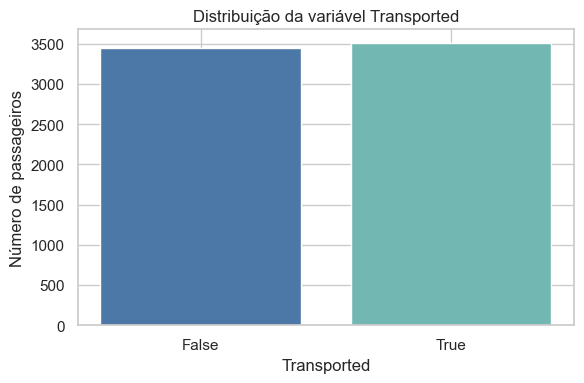

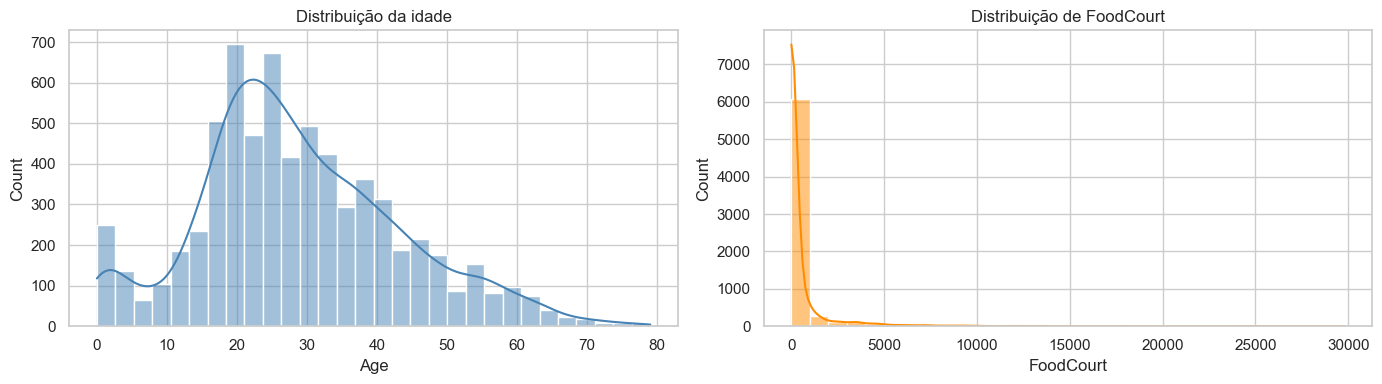

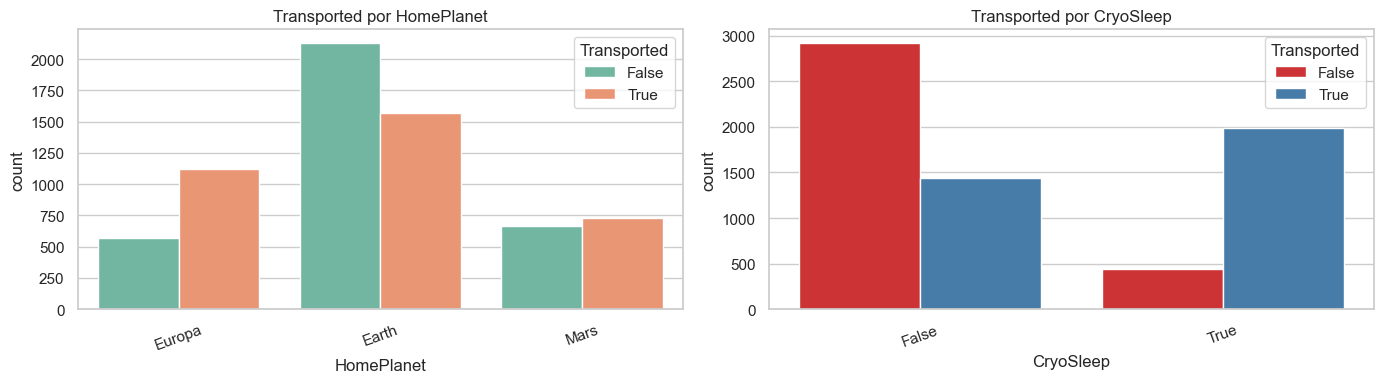

In [12]:
# Visão geral do dataset
print(f"Dimensão do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")
print("\nColunas:")
print(df.columns.tolist())

# Valores em falta por coluna
missing_values = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_values / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    'missing_values': missing_values,
    'missing_pct': missing_pct
})
missing_table = missing_table[missing_table['missing_values'] > 0]
print("\nValores em falta por coluna:")
display(missing_table)

# Resumo estatístico das variáveis numéricas
print("\nResumo estatístico das variáveis numéricas:")
display(df.describe())

# Distribuição da variável alvo do O1
transported_counts = df['Transported'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(transported_counts.index.astype(str), transported_counts.values, color=['#4c78a8', '#72b7b2'])
plt.title('Distribuição da variável Transported')
plt.xlabel('Transported')
plt.ylabel('Número de passageiros')
plt.tight_layout()
plt.show()

# Distribuição de algumas variáveis numéricas importantes
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['Age'], kde=True, bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição da idade')
axes[0].set_xlabel('Age')

sns.histplot(df['FoodCourt'], kde=True, bins=30, ax=axes[1], color='darkorange')
axes[1].set_title('Distribuição de FoodCourt')
axes[1].set_xlabel('FoodCourt')

plt.tight_layout()
plt.show()

# Relação simples entre Transported e algumas variáveis categóricas
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=df, x='HomePlanet', hue='Transported', ax=axes[0], palette='Set2')
axes[0].set_title('Transported por HomePlanet')
axes[0].tick_params(axis='x', rotation=20)

sns.countplot(data=df, x='CryoSleep', hue='Transported', ax=axes[1], palette='Set1')
axes[1].set_title('Transported por CryoSleep')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## EDA inicial

Nesta fase vamos começar por perceber a estrutura do dataset, a presença de valores em falta e a distribuição das variáveis mais relevantes, incluindo a variável alvo do O1.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Criar uma cópia de trabalho para engenharia de variáveis
work_df = df.copy()

# Features derivadas a partir de Cabin
cabin_split = work_df['Cabin'].astype('string').str.split('/', expand=True)
work_df['CabinDeck'] = cabin_split[0]
work_df['CabinNum'] = pd.to_numeric(cabin_split[1], errors='coerce')
work_df['CabinSide'] = cabin_split[2]

# Separar variáveis explicativas e alvo base
base_target = 'Transported'
base_feature_columns = [
    'HomePlanet',
    'CryoSleep',
    'Destination',
    'Age',
    'VIP',
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck',
    'CabinDeck',
    'CabinNum',
    'CabinSide'
]

X_base = work_df[base_feature_columns].copy()
y_base = work_df[base_target].copy()

# Identificar colunas numéricas e categóricas
numeric_features = X_base.select_dtypes(include=['number', 'float64', 'int64']).columns.tolist()
categorical_features = X_base.select_dtypes(exclude=['number', 'float64', 'int64']).columns.tolist()

print('Variáveis numéricas:', numeric_features)
print('Variáveis categóricas:', categorical_features)

# Transformadores para o pipeline base
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_base = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# Pequeno resumo do que ficou preparado
print(f'Número de variáveis de entrada: {len(base_feature_columns)}')
print(f'Número de variáveis numéricas: {len(numeric_features)}')
print(f'Número de variáveis categóricas: {len(categorical_features)}')

Variáveis numéricas: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum']
Variáveis categóricas: ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'CabinDeck', 'CabinSide']
Número de variáveis de entrada: 13
Número de variáveis numéricas: 7
Número de variáveis categóricas: 6


## Pré-processamento base

Vamos preparar uma base comum para os modelos seguintes: tratamento de valores em falta, codificação de variáveis categóricas, normalização das variáveis numéricas e criação de algumas features úteis a partir de `Cabin`.

# Fase 2: Resolução dos Objetivos
## Objetivo 1 (O1): Prever a variável Transported

In [ ]:
# Código para o Objetivo 1...

## Objetivo 2 (O2): Prever o valor dispendido no FoodCourt

In [ ]:
# Código para o Objetivo 2...

## Objetivo 3 (O3): Prever a idade dos passageiros transportados

In [ ]:
# Código para o Objetivo 3...

# Fase 3: Importância dos Atributos (O4)

In [ ]:
# Código para extrair e desenhar gráficos da importância dos atributos dos melhores modelos acima...

# Fase 4: Discussão e Conclusões
Escrevam aqui as conclusões finais do projeto e respondam à pergunta do O3.